In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_csv("data/house_prices.csv")
print("Shape:", df.shape)

Shape: (187531, 21)


In [3]:
df.columns.tolist()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

In [4]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [6]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [7]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print("% missing per column:\n")
print(missing_pct.round(2).to_string())

% missing per column:

Plot Area            100.00
Dimensions           100.00
Society               58.49
Super Area            57.42
Car Parking           55.11
overlooking           43.43
Carpet Area           43.02
facing                37.45
Ownership             34.94
Balcony               26.09
Price (in rupees)      9.42
Floor                  3.77
Description            1.61
Furnishing             1.54
Bathroom               0.44
Status                 0.33
Transaction            0.04
Amount(in rupees)      0.00
Title                  0.00
Index                  0.00
location               0.00


In [8]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
print(f"Rows with a usable price: {df['price_clean'].notna().sum():,} / {len(df):,}")

Rows with a usable price: 177,847 / 187,531


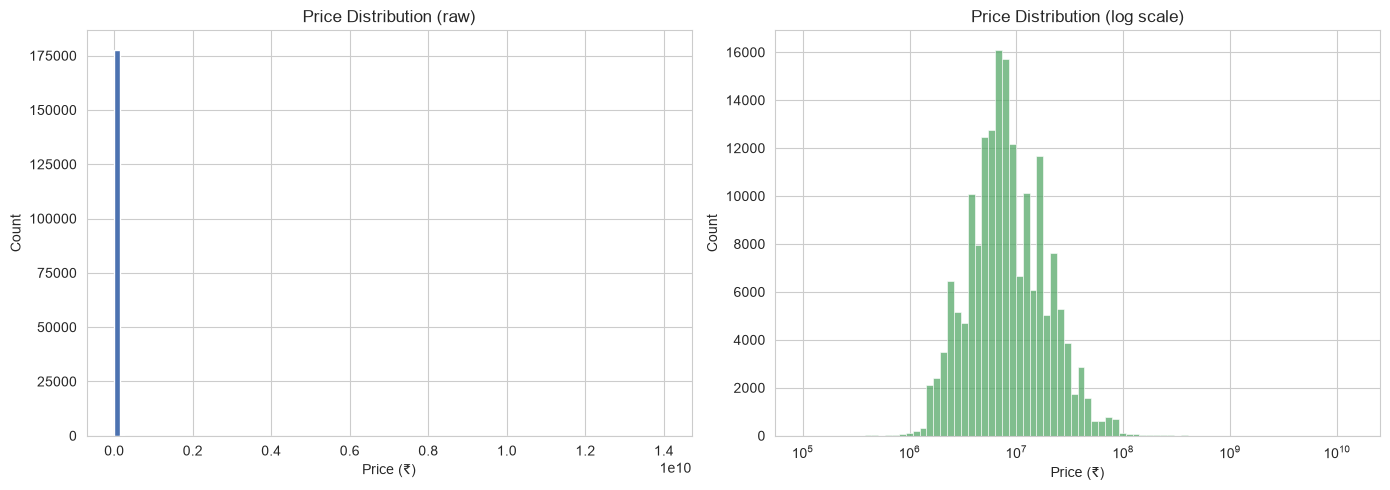

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price_clean"].dropna(), bins=100, color="#4c72b0", edgecolor="white")
axes[0].set_title("Price Distribution (raw)")
axes[0].set_xlabel("Price (₹)")
axes[0].set_ylabel("Count")

sns.histplot(df["price_clean"].dropna(), log_scale=True, bins=80, ax=axes[1],
             color="#55a868", edgecolor="white")
axes[1].set_title("Price Distribution (log scale)")
axes[1].set_xlabel("Price (₹)")

plt.tight_layout()
plt.show()

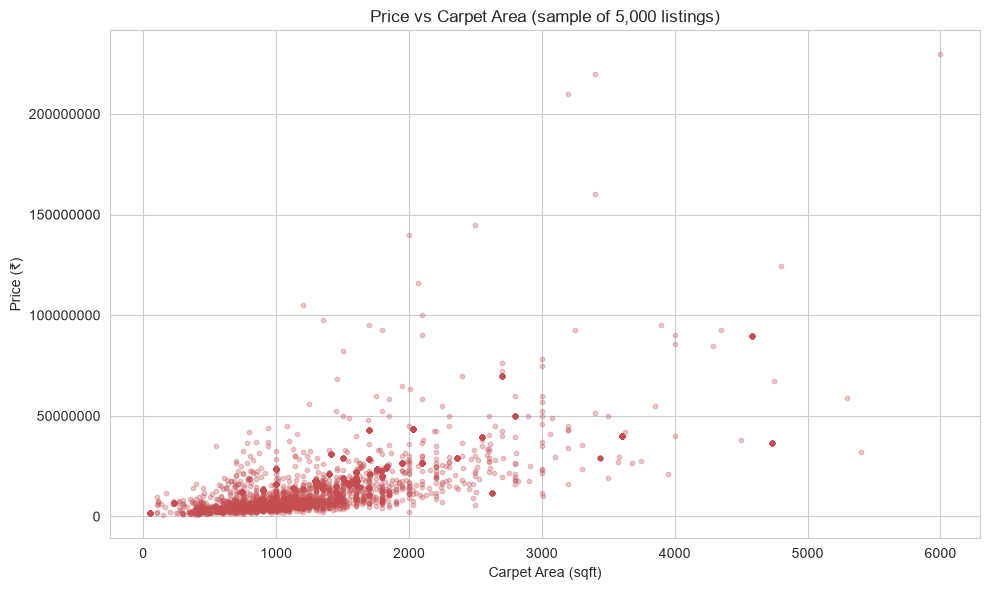

In [10]:
def parse_area(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    try:
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        return float(x.replace(",", ""))
    except ValueError:
        return np.nan

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

mask = df["price_clean"].notna() & df["carpet_area_sqft"].notna()
sample = df.loc[mask].sample(n=min(5000, mask.sum()), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample["carpet_area_sqft"], sample["price_clean"],
            alpha=0.3, s=10, color="#c44e52")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (₹)")
plt.title("Price vs Carpet Area (sample of 5,000 listings)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

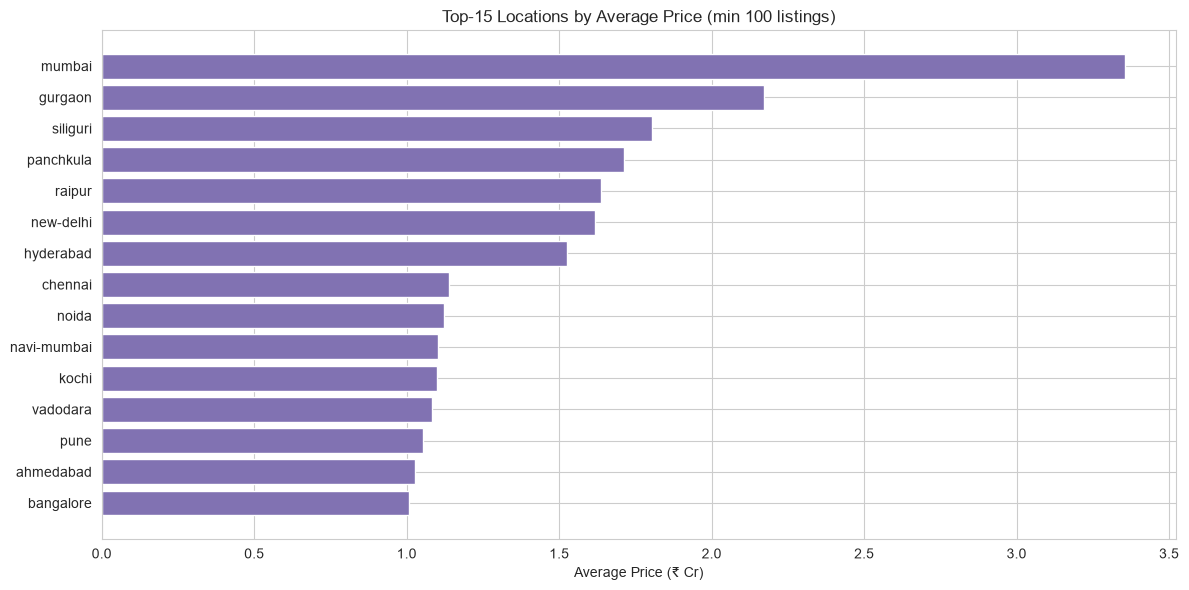

In [11]:
loc_price = (df.loc[df["price_clean"].notna()]
             .groupby("location")["price_clean"]
             .agg(["mean", "count"])
             .query("count >= 100")
             .nlargest(15, "mean"))

plt.figure(figsize=(12, 6))
plt.barh(loc_price.index[::-1], loc_price["mean"][::-1] / 1e7,
         color="#8172b2", edgecolor="white")
plt.xlabel("Average Price (₹ Cr)")
plt.title("Top-15 Locations by Average Price (min 100 listings)")
plt.tight_layout()
plt.show()

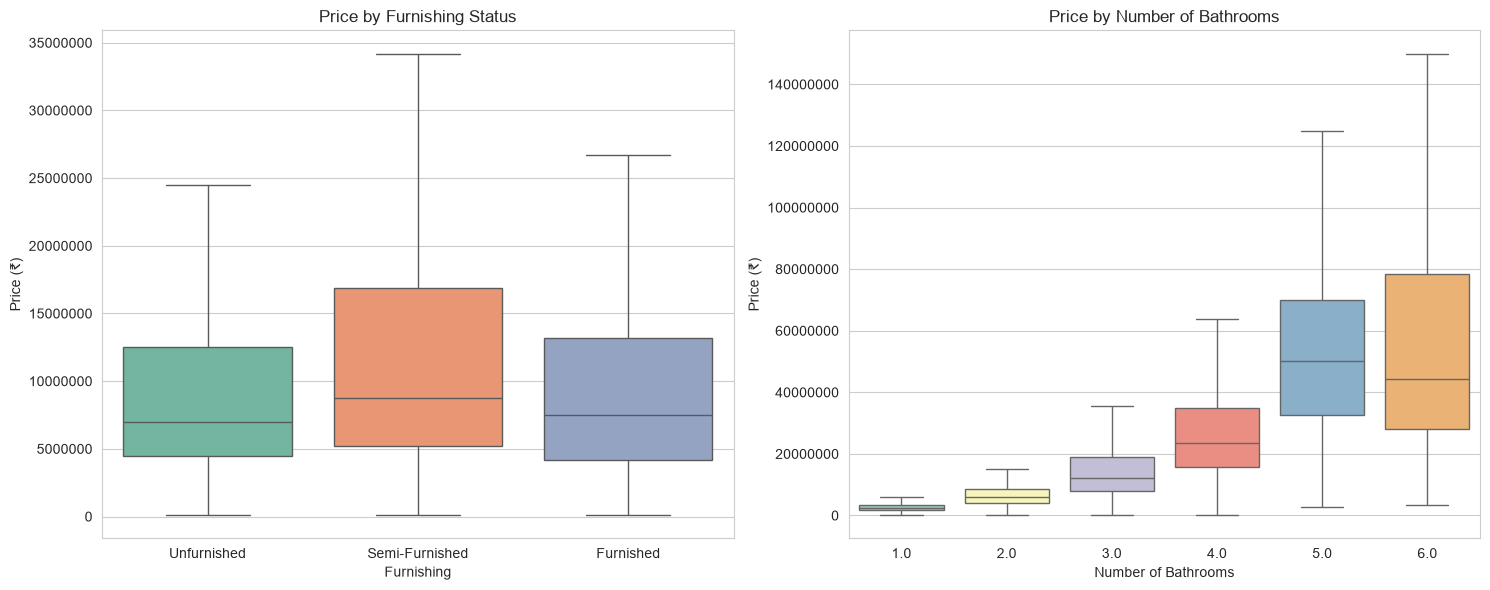

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

furn_data = df.loc[df["price_clean"].notna() & df["Furnishing"].notna()]
order = [o for o in ["Unfurnished", "Semi-Furnished", "Furnished"]
         if o in furn_data["Furnishing"].unique()]
sns.boxplot(data=furn_data, x="Furnishing", y="price_clean",
            order=order, ax=axes[0], palette="Set2", showfliers=False)
axes[0].set_ylabel("Price (₹)")
axes[0].set_title("Price by Furnishing Status")
axes[0].ticklabel_format(style="plain", axis="y")

df["bathroom_num"] = pd.to_numeric(df["Bathroom"], errors="coerce")
bath_data = df.loc[df["price_clean"].notna() & df["bathroom_num"].notna()]
bath_data = bath_data[bath_data["bathroom_num"].between(1, 6)]
sns.boxplot(data=bath_data, x="bathroom_num", y="price_clean",
            ax=axes[1], palette="Set3", showfliers=False)
axes[1].set_xlabel("Number of Bathrooms")
axes[1].set_ylabel("Price (₹)")
axes[1].set_title("Price by Number of Bathrooms")
axes[1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

In [13]:
print(f"Before: {len(df):,} rows")
df = df.dropna(subset=["price_clean"])
print(f"After: {len(df):,} rows")

Before: 187,531 rows
After: 177,847 rows


In [14]:
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

print("Carpet Area non-null:", df["carpet_area_sqft"].notna().sum())
print("Super Area  non-null:", df["super_area_sqft"].notna().sum())

df["area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
print("Combined    non-null:", df["area_sqft"].notna().sum())

Carpet Area non-null: 96856
Super Area  non-null: 72721
Combined    non-null: 169577


In [15]:
def parse_floor(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    if "basement" in x:
        return -1
    if "ground" in x:
        return 0
    if "out of" in x:
        try:
            return int(x.split("out of")[0].strip())
        except ValueError:
            return np.nan
    try:
        return int(x)
    except ValueError:
        return np.nan

df["floor_num"] = df["Floor"].apply(parse_floor)
print("Floor parsed non-null:", df["floor_num"].notna().sum())
print(df["floor_num"].describe())

Floor parsed non-null: 170898
count    170898.000000
mean          4.499029
std           4.701323
min          -1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64


In [16]:
df["bathroom_num"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["balcony_num"] = pd.to_numeric(df["Balcony"], errors="coerce")

def parse_car_parking(x):
    if not isinstance(x, str):
        return np.nan
    total = 0
    for part in x.split(","):
        part = part.strip()
        try:
            total += int(part.split()[0])
        except (ValueError, IndexError):
            pass
    return total if total > 0 else np.nan

df["parking_num"] = df["Car Parking"].apply(parse_car_parking)

for col in ["bathroom_num", "balcony_num", "parking_num", "floor_num"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: imputed missing with median = {median_val}")

bathroom_num: imputed missing with median = 2.0
balcony_num: imputed missing with median = 2.0
parking_num: imputed missing with median = 1.0
floor_num: imputed missing with median = 3.0


In [17]:
TOP_N = 50

def reduce_cardinality(series, top_n=TOP_N):
    top = series.value_counts().nlargest(top_n).index
    return series.where(series.isin(top), other="other")

df["location_clean"] = reduce_cardinality(df["location"].fillna("other"))
df["society_clean"] = reduce_cardinality(df["Society"].fillna("other"))

print(f"location: {df['location'].nunique()} unique -> {df['location_clean'].nunique()} categories")
print(f"Society:  {df['Society'].nunique()} unique -> {df['society_clean'].nunique()} categories")

location: 81 unique -> 51 categories
Society:  10068 unique -> 50 categories


In [18]:
drop_cols = ["Index", "Title", "Description", "Dimensions", "Plot Area",
             "Amount(in rupees)", "Price (in rupees)",
             "Carpet Area", "Super Area", "Floor",
             "Bathroom", "Balcony", "Car Parking",
             "location", "Society"]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f"Remaining columns ({len(df.columns)}):")
print(df.columns.tolist())

Remaining columns (16):
['Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership', 'price_clean', 'carpet_area_sqft', 'bathroom_num', 'super_area_sqft', 'area_sqft', 'floor_num', 'balcony_num', 'parking_num', 'location_clean', 'society_clean']


In [19]:
mask_area = df["area_sqft"].notna() & (df["area_sqft"] > 0)
df.loc[mask_area, "price_per_sqft"] = (
    df.loc[mask_area, "price_clean"] / df.loc[mask_area, "area_sqft"]
)

before = len(df)
low = df["price_per_sqft"].quantile(0.01)
high = df["price_per_sqft"].quantile(0.99)

df = df[
    df["price_per_sqft"].isna() |
    df["price_per_sqft"].between(low, high)
]
print(f"Outlier removal: {before:,} -> {len(df):,} rows (dropped {before - len(df):,})")
print(f"Price-per-sqft kept range: {low:,.0f} - {high:,.0f}")

df = df.drop(columns=["price_per_sqft"])

Outlier removal: 177,847 -> 174,475 rows (dropped 3,372)
Price-per-sqft kept range: 2,256 - 33,882


In [20]:
print(f"Final shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}\n")
print(f"Remaining nulls:\n{df.isna().sum()}\n")
df.head()

Final shape: (174475, 16)

Column types:
Status                  str
Transaction             str
Furnishing              str
facing                  str
overlooking             str
Ownership               str
price_clean         float64
carpet_area_sqft    float64
bathroom_num        float64
super_area_sqft     float64
area_sqft           float64
floor_num           float64
balcony_num         float64
parking_num         float64
location_clean          str
society_clean           str
dtype: object



Remaining nulls:
Status                 589
Transaction             66
Furnishing            2040
facing               63450
overlooking          73485
Ownership            59699
price_clean              0
carpet_area_sqft     79577
bathroom_num             0
super_area_sqft     103168
area_sqft             8270
floor_num                0
balcony_num              0
parking_num              0
location_clean           0
society_clean            0
dtype: int64



,Status,Transaction,Furnishing,facing,overlooking,Ownership,price_clean,carpet_area_sqft,bathroom_num,super_area_sqft,area_sqft,floor_num,balcony_num,parking_num,location_clean,society_clean
0,Ready to Move,Resale,Unfurnished,NaN,NaN,NaN,4200000.0,500.0,1.0,NaN,500.0,10.0,2.0,1.0,thane,other
1,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,Freehold,9800000.0,473.0,2.0,NaN,473.0,3.0,2.0,1.0,thane,other
2,Ready to Move,Resale,Unfurnished,East,Garden/Park,Freehold,14000000.0,779.0,2.0,NaN,779.0,10.0,2.0,1.0,thane,other
3,Ready to Move,Resale,Unfurnished,NaN,NaN,NaN,2500000.0,530.0,1.0,NaN,530.0,1.0,1.0,1.0,thane,other
4,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",Co-operative Society,16000000.0,635.0,2.0,NaN,635.0,20.0,2.0,1.0,thane,other


In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.base import clone
import sklearn, joblib, json, time

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


In [22]:
numeric_features = ["area_sqft", "floor_num", "bathroom_num", "balcony_num", "parking_num"]
categorical_features = ["location_clean", "Furnishing", "Transaction", "Ownership",
                         "facing", "Status"]

X = df[numeric_features + categorical_features].copy()
y = df["price_clean"].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny stats:\n{y.describe()}")

X shape: (174475, 11)
y shape: (174475,)

y stats:
count    1.744750e+05
mean     1.173170e+07
std      1.260493e+07
min      2.000000e+05
25%      5.000000e+06
50%      7.800000e+06
75%      1.450000e+07
max      8.000000e+08
Name: price_clean, dtype: float64


In [23]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")

Train: 139,580   Test: 34,895


In [25]:
regressors = {
    "LinearRegression":  LinearRegression(),
    "RandomForest":      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting":  GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                    max_depth=5, random_state=42),
}

results = []

for name, reg in regressors.items():
    for use_log in [False, True]:
        label = f"{name} ({'log' if use_log else 'raw'})"
        print(f"\n{'='*60}")
        print(f"Training: {label}")

        pipe = Pipeline([("prep", clone(preprocessor)), ("reg", clone(reg))])

        yt = np.log1p(y_train) if use_log else y_train

        t0 = time.time()
        pipe.fit(X_train, yt)
        train_time = time.time() - t0

        preds = pipe.predict(X_test)
        if use_log:
            preds = np.expm1(preds)

        mae  = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)
        r2   = r2_score(y_test, preds)

        results.append({
            "Model": label,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "Train time (s)": round(train_time, 1),
            "pipeline": pipe,
            "preds": preds,
            "use_log": use_log,
        })

        print(f"  MAE : {mae:,.0f}")
        print(f"  RMSE: {rmse:,.0f}")
        print(f"  R2  : {r2:.4f}")
        print(f"  Time: {train_time:.1f}s")


Training: LinearRegression (raw)


  MAE : 4,328,764
  RMSE: 7,810,284
  R2  : 0.6041
  Time: 1.1s

Training: LinearRegression (log)


  MAE : 4,119,116
  RMSE: 15,794,340
  R2  : -0.6192
  Time: 1.0s

Training: RandomForest (raw)


  MAE : 980,945
  RMSE: 4,177,399
  R2  : 0.8867
  Time: 30.6s

Training: RandomForest (log)


  MAE : 963,055
  RMSE: 4,241,550
  R2  : 0.8832
  Time: 28.0s

Training: GradientBoosting (raw)


  MAE : 2,088,845
  RMSE: 4,516,095
  R2  : 0.8676
  Time: 87.7s

Training: GradientBoosting (log)


  MAE : 2,122,286
  RMSE: 5,469,723
  R2  : 0.8058
  Time: 89.0s


In [26]:
results_df = pd.DataFrame(results).drop(columns=["pipeline", "preds", "use_log"])
results_df["MAE"] = results_df["MAE"].apply(lambda x: f"{x:,.0f}")
results_df["RMSE"] = results_df["RMSE"].apply(lambda x: f"{x:,.0f}")
results_df["R2"] = results_df["R2"].apply(lambda x: f"{x:.4f}")
print(results_df.to_string(index=False))

                 Model       MAE       RMSE      R2  Train time (s)
LinearRegression (raw) 4,328,764  7,810,284  0.6041             1.1
LinearRegression (log) 4,119,116 15,794,340 -0.6192             1.0
    RandomForest (raw)   980,945  4,177,399  0.8867            30.6
    RandomForest (log)   963,055  4,241,550  0.8832            28.0
GradientBoosting (raw) 2,088,845  4,516,095  0.8676            87.7
GradientBoosting (log) 2,122,286  5,469,723  0.8058            89.0


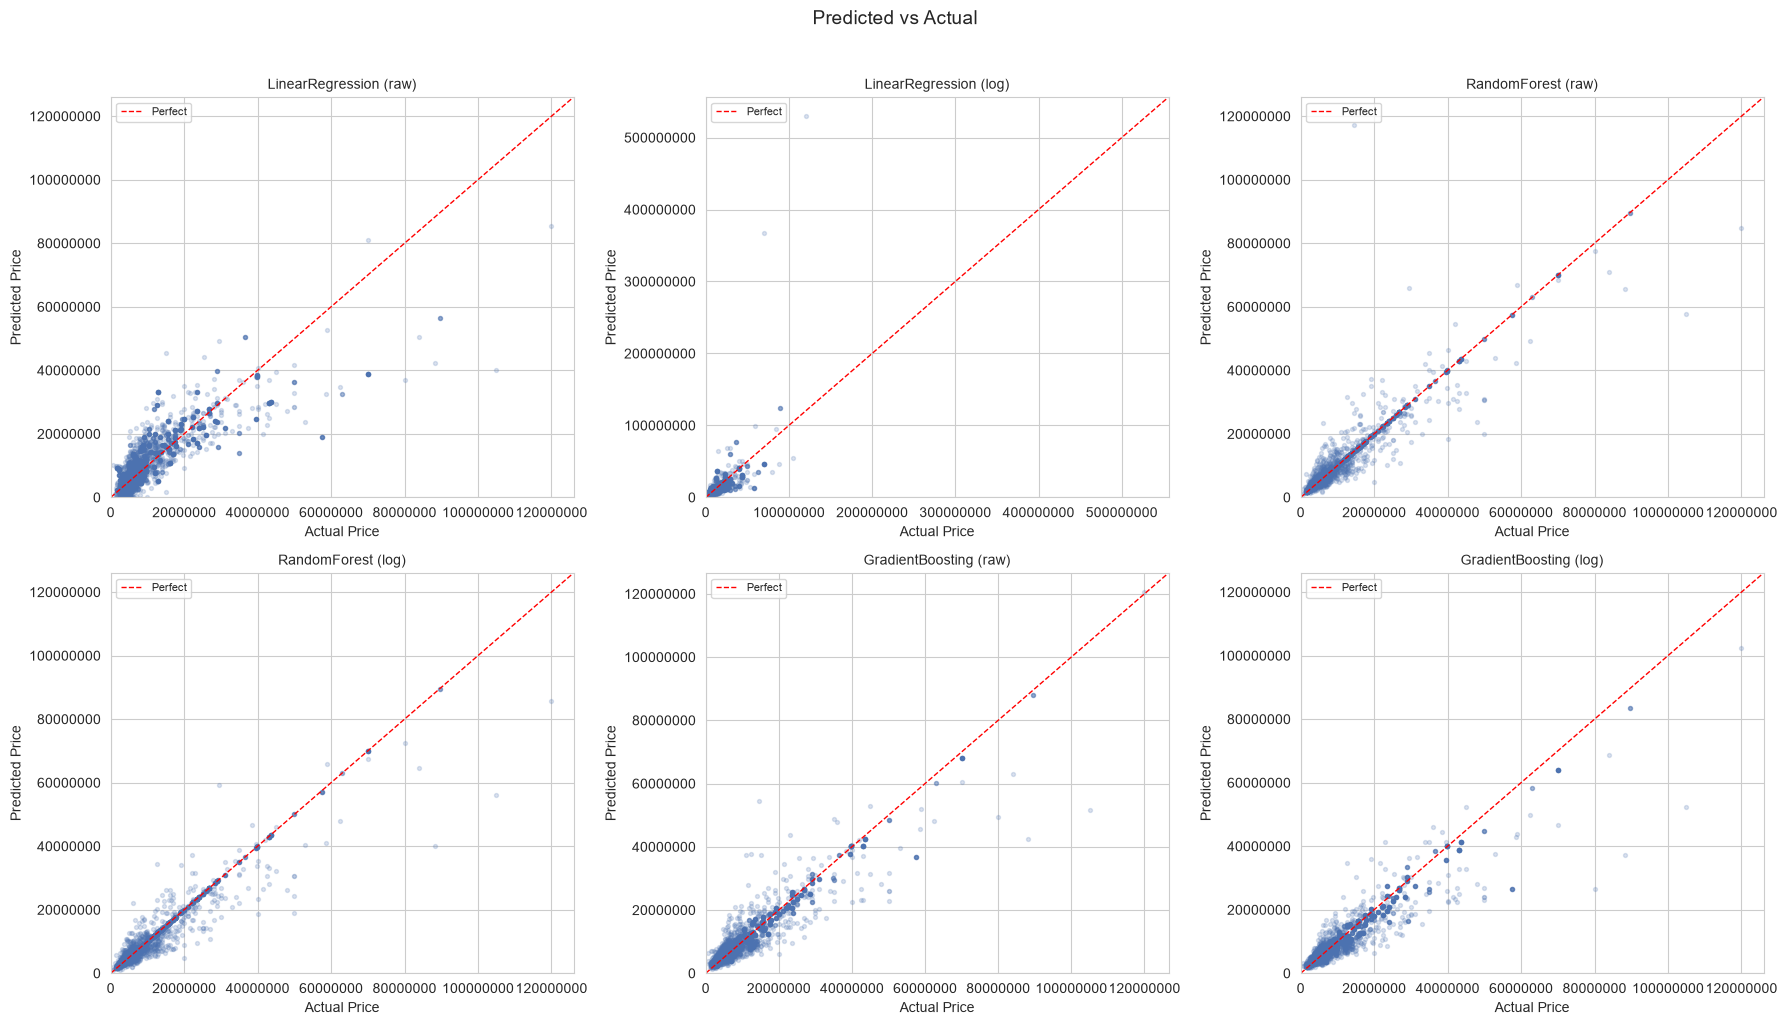

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, res in enumerate(results):
    ax = axes[i]
    sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(3000, len(y_test)), replace=False)
    actual = y_test.values[sample_idx]
    predicted = res["preds"][sample_idx]

    ax.scatter(actual, predicted, alpha=0.2, s=8, color="#4c72b0")
    lim_max = max(actual.max(), predicted.max()) * 1.05
    ax.plot([0, lim_max], [0, lim_max], "r--", linewidth=1, label="Perfect")
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(res["Model"], fontsize=10)
    ax.legend(fontsize=8)
    ax.ticklabel_format(style="plain", axis="both")

plt.suptitle("Predicted vs Actual", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
best_idx = max(range(len(results)), key=lambda i: float(results[i]["R2"]))
best = results[best_idx]
print(f"Best model: {best['Model']}")
print(f"  MAE : {best['MAE']:,.0f}")
print(f"  RMSE: {best['RMSE']:,.0f}")
print(f"  R2  : {best['R2']:.4f}")

Best model: RandomForest (raw)
  MAE : 980,945
  RMSE: 4,177,399
  R2  : 0.8867


In [29]:
best_pipe = best["pipeline"]
yt_cv = np.log1p(y) if best["use_log"] else y

cv_scores = cross_val_score(best_pipe, X, yt_cv, cv=5, scoring="r2", n_jobs=-1)
print(f"5-fold CV R2 scores: {cv_scores.round(4)}")
print(f"Mean R2: {cv_scores.mean():.4f}  +/-  {cv_scores.std():.4f}")

5-fold CV R2 scores: [0.6717 0.5138 0.8586 0.292  0.0631]
Mean R2: 0.4799  +/-  0.2794


In [30]:
joblib.dump(best_pipe, "house_price.pkl")
print("Model saved to house_price.pkl")

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
pred = loaded.predict(sample)
if best["use_log"]:
    pred = np.expm1(pred)
print(f"\nReloaded prediction: {pred[0]:,.0f}")
print(f"Actual value:        {y_test.iloc[0]:,.0f}")

Model saved to house_price.pkl



Reloaded prediction: 57,390,183
Actual value:        57,600,000


In [31]:
locations = sorted(df["location_clean"].unique().tolist())
json.dump(locations, open("locations.json", "w"))
print(f"Saved {len(locations)} locations to locations.json")
print("First 10:", locations[:10])

Saved 51 locations to locations.json
First 10: ['agra', 'ahmedabad', 'aurangabad', 'badlapur', 'bangalore', 'bhiwadi', 'bhubaneswar', 'chandigarh', 'chennai', 'coimbatore']


In [32]:
print(f"\nPin these in requirements.txt:")
print(f"scikit-learn=={sklearn.__version__}")
print(f"numpy=={np.__version__}")
print(f"pandas=={pd.__version__}")


Pin these in requirements.txt:
scikit-learn==1.9.0
numpy==2.5.2
pandas==3.0.5
